## Baseline Model for 1 Hour and 2 Hour Datasets
### Logistic Regresssion

In [1]:
#import libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

2026-07-10 14:39:38.726677: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#loading the data
one_hr_df = pd.read_csv("Final_Datasets/combined_data_1h.csv")
two_hr_df = pd.read_csv("Final_Datasets/combined_data_2h.csv")

In [3]:
#feature selection


target = "outcome"

numeric_features = [
    "scheduled_elapsed_time_minutes",
    "year",
    "month",
    "day_of_week",
    "is_weekend",
    "sched_dep_hour",
    "days_until_holiday",
    "days_from_holiday",
    "year_mfr",
    "no_seats",
    "visibility",
    "ceiling_height",
    "wind_speed",
    "wind_direction",
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "altimeter",
    "aircraft_age",
    "week_num",
    "temperature_dewpoint_spread",
    "airport_delay_average_1h",
    "airport_delay_stddev_1h",
    "airport_departures_observed_1h"]

categorical_features = [
    "carrier_code",
    "destination_airport",
    "model"]

## 1 Hour Dataset

In [4]:
#fix data types (datetime specifically) and sort in chronological order
one_hr_df["date"] = pd.to_datetime(one_hr_df["date"], errors="coerce")
one_hr_df["scheduled_dep_dt"] = pd.to_datetime(one_hr_df["scheduled_dep_dt"], errors="coerce")
one_hr_df = one_hr_df.sort_values("scheduled_dep_dt").reset_index(drop=True)
one_hr_df["outcome"] = one_hr_df["outcome"].astype(int)

In [5]:
#split into train / val / test 
#train: 2022-2023, val: 2024, test: >= 2025 
one_train_df = one_hr_df[one_hr_df["date"] < "2024-01-01"]
one_val_df = one_hr_df[(one_hr_df["date"] >= "2024-01-01") & (one_hr_df["date"] < "2025-01-01")]
one_test_df = one_hr_df[one_hr_df["date"] >= "2025-01-01"]

print("Train rows:", len(one_train_df))
print("Validation rows:", len(one_val_df))
print("Test rows:", len(one_test_df))

Train rows: 151575
Validation rows: 84531
Test rows: 97980


In [6]:
#split into X and y 
one_X_train = one_train_df[numeric_features + categorical_features]
one_y_train = one_train_df[target]

one_X_val = one_val_df[numeric_features + categorical_features]
one_y_val = one_val_df[target]

one_X_test = one_test_df[numeric_features + categorical_features]
one_y_test = one_test_df[target]

### some preprocessing

In [7]:
#scaling the numeric columns
#one hot encode the categorical columns
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)])

one_X_train_processed = preprocessor.fit_transform(one_X_train)
one_X_val_processed = preprocessor.transform(one_X_val)
one_X_test_processed = preprocessor.transform(one_X_test)

print("Train shape:", one_X_train_processed.shape)
print("Validation shape:", one_X_val_processed.shape)
print("Test shape:", one_X_test_processed.shape)

Train shape: (151575, 173)
Validation shape: (84531, 173)
Test shape: (97980, 173)


In [8]:
#check how imbalanced the classes are
one_train_df["outcome"].value_counts().sort_index()

outcome
0    92216
1    50499
2     5459
3     1642
4      673
5      299
6      175
7      224
8      388
Name: count, dtype: int64

In [9]:
#give more weight to cancelled and delayed classes so the model doesn't just ignore them as rare cases
from sklearn.utils.class_weight import compute_class_weight

one_num_classes = one_hr_df["outcome"].nunique()

one_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(one_num_classes),
    y=one_y_train
)
one_class_weights = np.sqrt(one_class_weights) 
one_class_weight_dict = {i: w for i, w in enumerate(one_class_weights)}
one_class_weight_dict

{0: 0.4273555944889481,
 1: 0.5774988778287594,
 2: 1.7564507891577426,
 3: 3.202624025641207,
 4: 5.002475860513205,
 5: 7.5051078853086866,
 6: 9.810101693565427,
 7: 8.670986789562184,
 8: 6.588350126421345}

In [10]:
#build the model
tf.keras.backend.clear_session()
tf.random.set_seed(42)

one_model = tf.keras.Sequential([
    tf.keras.Input(shape=(one_X_train_processed.shape[1],)),
    tf.keras.layers.Dense(one_num_classes, activation="softmax")
])

one_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

one_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 9)              │         1,566 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,566 (6.12 KB)

 Trainable params: 1,566 (6.12 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#train the model and using early stopping 

one_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

one_trained_model = one_model.fit(
    one_X_train_processed,
    one_y_train,
    validation_data=(one_X_val_processed, one_y_val),
    epochs=50,
    batch_size=512,
    class_weight=one_class_weight_dict,
    callbacks=[one_early_stop],
    verbose=0
)

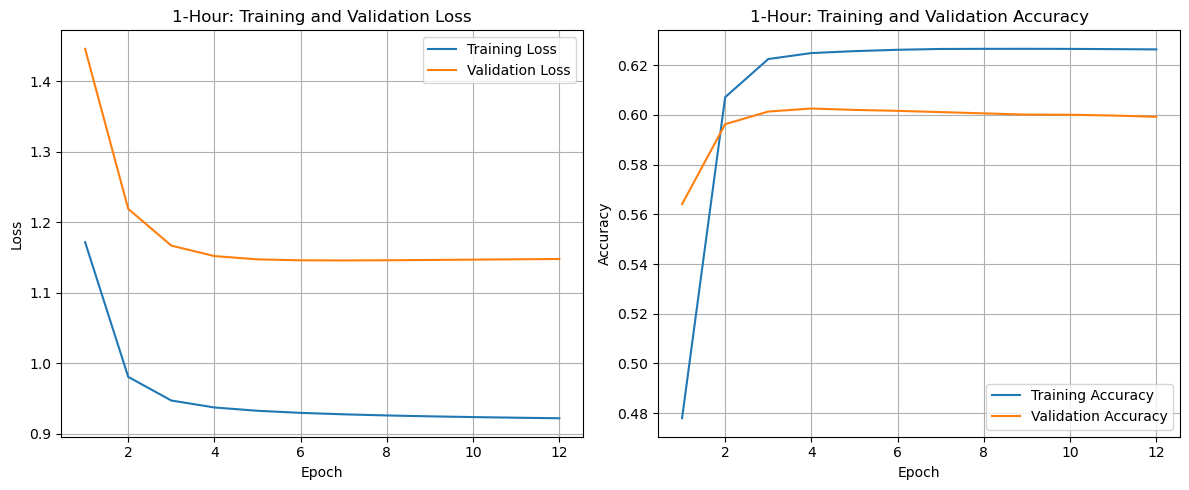

In [12]:
#plotting loss & Accuracy
num_epochs = len(one_trained_model.history["loss"])
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, one_trained_model.history["loss"], label="Training Loss")
plt.plot(epochs, one_trained_model.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1-Hour: Training and Validation Loss")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs, one_trained_model.history["accuracy"], label="Training Accuracy")
plt.plot(epochs, one_trained_model.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("1-Hour: Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [31]:
#loss and Accuracy on train, val, and test sets
one_train_loss, one_train_acc = one_model.evaluate(one_X_train_processed, one_y_train, verbose=0)
one_val_loss, one_val_acc = one_model.evaluate(one_X_val_processed, one_y_val, verbose=0)
one_test_loss, one_test_acc = one_model.evaluate(one_X_test_processed, one_y_test, verbose=0)

print(f"Train Loss: {one_train_loss}")
print(f"Train Accuracy: {one_train_acc}")

print(f"\nValidation Loss: {one_val_loss}")
print(f"Validation Accuracy: {one_val_acc}")

print(f"\nTest Loss: {one_test_loss}")
print(f"Test Accuracy: {one_test_acc}")

Train Loss: 1.0305416584014893
Train Accuracy: 0.6268184185028076

Validation Loss: 1.1459535360336304
Validation Accuracy: 0.6011285781860352

Test Loss: 1.2013535499572754
Test Accuracy: 0.6201061606407166


In [32]:
#balanced accuracy 
#breakdown on the test set per class
one_test_probs = one_model.predict(one_X_test_processed, batch_size=512, verbose=0)
one_test_preds = np.argmax(one_test_probs, axis=1)

one_balanced_acc = balanced_accuracy_score(one_y_test, one_test_preds)
print(f"Test Balanced Accuracy: {one_balanced_acc}")
print()
print(classification_report(one_y_test, one_test_preds, zero_division=0))

Test Balanced Accuracy: 0.139421276810867

              precision    recall  f1-score   support

           0       0.71      0.80      0.75     62608
           1       0.43      0.36      0.39     28762
           2       0.12      0.08      0.10      3951
           3       0.00      0.00      0.00      1310
           4       0.00      0.00      0.00       523
           5       0.00      0.00      0.00       246
           6       0.00      0.00      0.00       112
           7       0.01      0.01      0.01       171
           8       0.00      0.00      0.00       297

    accuracy                           0.62     97980
   macro avg       0.14      0.14      0.14     97980
weighted avg       0.58      0.62      0.60     97980



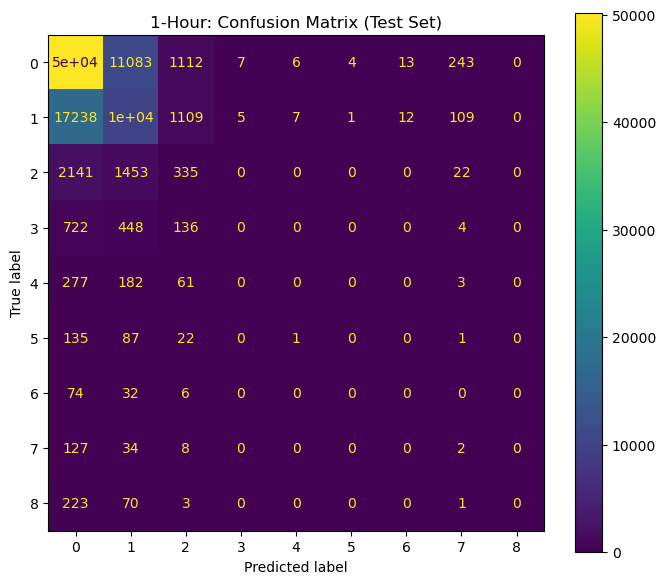

In [15]:
#confusion matrix 

one_cm = confusion_matrix(one_y_test, one_test_preds)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(one_cm)
disp.plot(ax=ax)
plt.title("1-Hour: Confusion Matrix (Test Set)")
plt.show()

## 2 Hour Dataset

In [16]:
#fix data types and sort in chronological order
two_hr_df["date"] = pd.to_datetime(two_hr_df["date"], errors="coerce")
two_hr_df["scheduled_dep_dt"] = pd.to_datetime(two_hr_df["scheduled_dep_dt"], errors="coerce")
two_hr_df = two_hr_df.sort_values("scheduled_dep_dt").reset_index(drop=True)
two_hr_df["outcome"] = two_hr_df["outcome"].astype(int)

In [17]:
#split into train / val / test by date
two_train_df = two_hr_df[two_hr_df["date"] < "2024-01-01"]
two_val_df = two_hr_df[(two_hr_df["date"] >= "2024-01-01") & (two_hr_df["date"] < "2025-01-01")]
two_test_df = two_hr_df[two_hr_df["date"] >= "2025-01-01"]

print("Train rows:", len(two_train_df))
print("Validation rows:", len(two_val_df))
print("Test rows:", len(two_test_df))

Train rows: 151962
Validation rows: 84932
Test rows: 99024


In [18]:
#split into X and Y
two_X_train = two_train_df[numeric_features + categorical_features]
two_y_train = two_train_df[target]

two_X_val = two_val_df[numeric_features + categorical_features]
two_y_val = two_val_df[target]

two_X_test = two_test_df[numeric_features + categorical_features]
two_y_test = two_test_df[target]

### Preprocessing

In [19]:
preprocessor_2h = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

two_X_train_processed = preprocessor_2h.fit_transform(two_X_train)
two_X_val_processed = preprocessor_2h.transform(two_X_val)
two_X_test_processed = preprocessor_2h.transform(two_X_test)

print("Train shape:", two_X_train_processed.shape)
print("Validation shape:", two_X_val_processed.shape)
print("Test shape:", two_X_test_processed.shape)

Train shape: (151962, 173)
Validation shape: (84932, 173)
Test shape: (99024, 173)


In [20]:
#adjusting weights
two_num_classes = two_hr_df["outcome"].nunique()

two_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(two_num_classes),
    y=two_y_train
)
two_class_weights = np.sqrt(two_class_weights)
two_class_weight_dict = {i: w for i, w in enumerate(two_class_weights)}
two_class_weight_dict

{0: 0.4273150266332506,
 1: 0.5775897744723457,
 2: 1.7575651476406216,
 3: 3.206709875517423,
 4: 5.001431893733466,
 5: 7.5146827663683,
 6: 9.658439376889696,
 7: 8.458439438815708,
 8: 6.648360555827221}

In [21]:
#baseline model
tf.keras.backend.clear_session()
tf.random.set_seed(42)

two_model = tf.keras.Sequential([
    tf.keras.Input(shape=(two_X_train_processed.shape[1],)),
    tf.keras.layers.Dense(two_num_classes, activation="softmax")
])

two_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

two_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 9)              │         1,566 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,566 (6.12 KB)

 Trainable params: 1,566 (6.12 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#train the model
two_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

two_trained_model = two_model.fit(
    two_X_train_processed,
    two_y_train,
    validation_data=(two_X_val_processed, two_y_val),
    epochs=50,
    batch_size=512,
    class_weight=two_class_weight_dict,
    callbacks=[two_early_stop],
    verbose=0
)

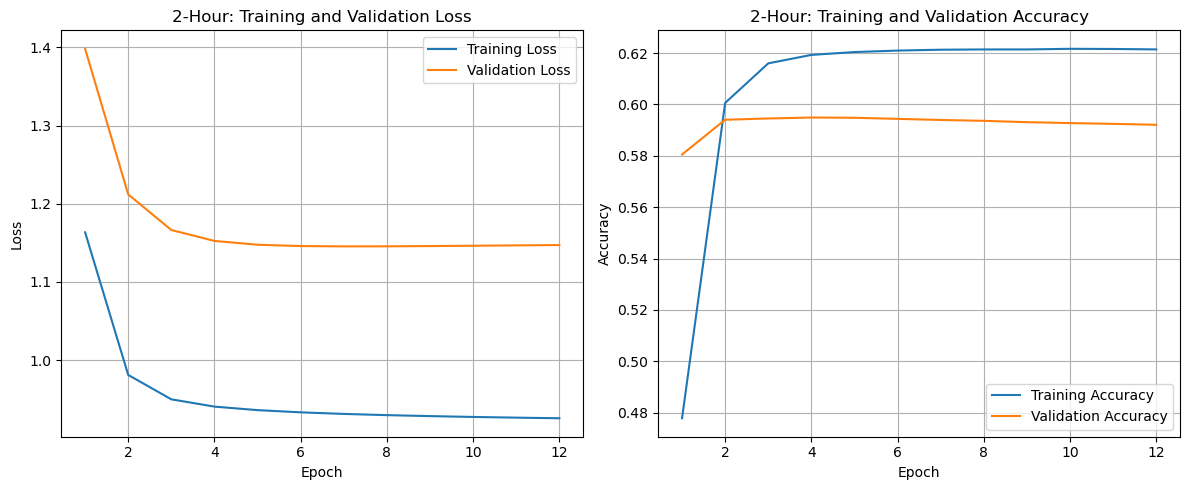

In [23]:
#plotting loss and accuracy
num_epochs = len(two_trained_model.history["loss"])
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, two_trained_model.history["loss"], label="Training Loss")
plt.plot(epochs, two_trained_model.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("2-Hour: Training and Validation Loss")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs, two_trained_model.history["accuracy"], label="Training Accuracy")
plt.plot(epochs, two_trained_model.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("2-Hour: Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [29]:
#loss and accuracy on train, val, and test
two_train_loss, two_train_acc = two_model.evaluate(two_X_train_processed, two_y_train, verbose=0)
two_val_loss, two_val_acc = two_model.evaluate(two_X_val_processed, two_y_val, verbose=0)
two_test_loss, two_test_acc = two_model.evaluate(two_X_test_processed, two_y_test, verbose=0)

print(f"Train Loss: {two_train_loss}")
print(f"Train Accuracy: {two_train_acc}")

print(f"\nValidation Loss: {two_val_loss}")
print(f"Validation Accuracy: {two_val_acc}")

print(f"\nTest Loss: {two_test_loss}")
print(f"Test Accuracy: {two_test_acc}")

Train Loss: 1.0319229364395142
Train Accuracy: 0.6207801699638367

Validation Loss: 1.145500898361206
Validation Accuracy: 0.5939692854881287

Test Loss: 1.208569884300232
Test Accuracy: 0.6005412936210632


In [30]:
#balanced accuracy
two_test_probs = two_model.predict(two_X_test_processed, batch_size=512, verbose=0)
two_test_preds = np.argmax(two_test_probs, axis=1)

two_balanced_acc = balanced_accuracy_score(two_y_test, two_test_preds)
print(f"Test Balanced Accuracy: {two_balanced_acc}")
print()
print(classification_report(two_y_test, two_test_preds, zero_division=0))

Test Balanced Accuracy: 0.13467955741736093

              precision    recall  f1-score   support

           0       0.70      0.76      0.73     63389
           1       0.40      0.39      0.40     28909
           2       0.09      0.04      0.06      4042
           3       0.05      0.00      0.01      1350
           4       0.00      0.00      0.00       523
           5       0.00      0.00      0.00       246
           6       0.00      0.00      0.00       107
           7       0.01      0.02      0.01       163
           8       0.00      0.00      0.00       295

    accuracy                           0.60     99024
   macro avg       0.14      0.13      0.13     99024
weighted avg       0.57      0.60      0.58     99024



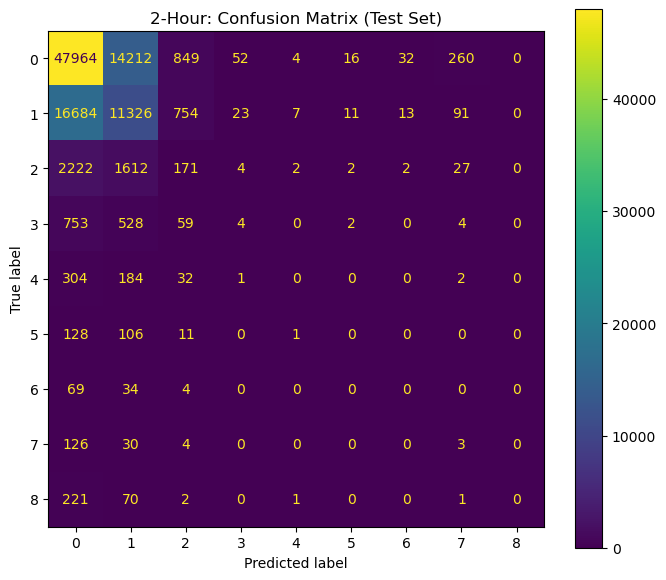

In [26]:
#confusion matrix
two_cm = confusion_matrix(two_y_test, two_test_preds)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(two_cm)
disp.plot(ax=ax)
plt.title("2-Hour: Confusion Matrix (Test Set)")
plt.show()

**1 Hr Dataset:**
Test Accuracy = 0.618
Test Balanced Accuracy = 0.142

**2 Hr Dataset:**
Test Accuracy = 0.597
Test Balanced Accuracy = 0.136


Model isn't working well for 2+ hour delays and cancellations. Random Forest and neural network models should hopefully help build a better model
